Ciao!

In generale, qualche commento in piu' nel codice per favore!
Sia nel codice che come descrizione delle funzioni definite

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

3145915


In [2]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [3]:
def build_graph_topk(
    filename,
    sequence,
    score_map,
    distance_map=None,
    sep_min=0,
    k=50
):
    N = len(sequence)

    score_map = torch.tensor(score_map, dtype=torch.float)
    score_map = (score_map - score_map.mean()) / (score_map.std() + 1e-6)

    idx = torch.arange(N)

    # optional distance
    if distance_map is not None:
        distance_map = torch.tensor(distance_map, dtype=torch.float)
        distance_map = torch.log(distance_map / 8)
    else:
        distance_map = None



    edge_set = set()
    for i in range(N):     # <<<< per forza con un for? magari si vettorializza con poco sforzo
        candidates = torch.arange(N)

        # masks
        mask = (candidates != i) & (torch.abs(candidates - i) >= sep_min)
        candidates = candidates[mask]

        if candidates.numel() == 0:
            continue

        scores = score_map[i, candidates]

        # top-k
        if candidates.numel() > k:
            topk = torch.topk(scores, k=k).indices
            candidates = candidates[topk]

        for j in candidates.tolist():
            edge_set.add((i, j))
            edge_set.add((j, i))


    edges = torch.tensor(list(edge_set), dtype=torch.long)
    src, dst = edges[:, 0], edges[:, 1]

    edge_index = torch.stack([src, dst], dim=0)

    # --- build pairwise features (same as original) ---
    sep = torch.abs(src - dst).float()
    sep_bucket = torch.clamp(sep, max=32).long()

    edge_scores = score_map[src, dst]

    edge_attr = torch.stack([edge_scores, sep_bucket.float()], dim=-1)

    # --- labels ---
    if distance_map is not None:
        labels = distance_map[src, dst]
        known = torch.isfinite(labels)
    else:
        labels = torch.zeros_like(edge_scores)
        known = torch.ones_like(edge_scores, dtype=torch.bool)

    y = labels.unsqueeze(-1)

    # --- masks ---
    not_self = src != dst
    long_range_ok = sep >= sep_min
    edge_mask = known & long_range_ok & not_self
    pair_mask = src < dst  # upper triangle

    # --- reverse edge index ---
    edge_to_idx = {
        (int(s), int(d)): k for k, (s, d) in enumerate(zip(src.tolist(), dst.tolist()))   # <<<< Non usare k, gia' in uso per altra variabile
    }

    rev_edge_idx = torch.tensor(
        [edge_to_idx[(int(d), int(s))] for s, d in zip(src.tolist(), dst.tolist())],
        dtype=torch.long
    )

    # --- node features ---
    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        edge_mask=edge_mask,
        pair_mask=pair_mask,
        rev_edge_idx=rev_edge_idx,    # <<<< sicuro che serva? edge_idx contiene gia' i reverse dalla costruzione nel set. In piu' ha size [2M], mentre edge_idx ha size [2,2M]. Non capisco perche'
        filename=filename
    )

In [4]:
folder_path = "Data"

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):    #and (file== "data_PF00014.pkl" or file== "data_PF01640.pkl")
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        filename=str(file)
        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']
        data = build_graph_topk(filename,sequence, contact_map_DCA, distance_map)
        all_data.append(data)


from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# train_loader=DataLoader(all_data, batch_size=1, shuffle=True) 
# test_loader=DataLoader(all_data, batch_size=1, shuffle=True) 

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=0)


train_loader = DataLoader(train_data, batch_size=1, shuffle=True) 
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [5]:
print(train_loader)

with torch.no_grad():
    for batch in train_loader:
        print(batch)

DataBatch(x=[45, 16], edge_index=[2, 1980], edge_attr=[1980, 2], y=[1980, 1], edge_mask=[1980], pair_mask=[1980], rev_edge_idx=[1980], filename=[1], batch=[45], ptr=[2])
DataBatch(x=[60, 16], edge_index=[2, 3142], edge_attr=[3142, 2], y=[3142, 1], edge_mask=[3142], pair_mask=[3142], rev_edge_idx=[3142], filename=[1], batch=[60], ptr=[2])
DataBatch(x=[105, 16], edge_index=[2, 5538], edge_attr=[5538, 2], y=[5538, 1], edge_mask=[5538], pair_mask=[5538], rev_edge_idx=[5538], filename=[1], batch=[105], ptr=[2])
DataBatch(x=[95, 16], edge_index=[2, 5134], edge_attr=[5134, 2], y=[5134, 1], edge_mask=[5134], pair_mask=[5134], rev_edge_idx=[5134], filename=[1], batch=[95], ptr=[2])
DataBatch(x=[204, 16], edge_index=[2, 11098], edge_attr=[11098, 2], y=[11098, 1], edge_mask=[11098], pair_mask=[11098], rev_edge_idx=[11098], filename=[1], batch=[204], ptr=[2])
DataBatch(x=[167, 16], edge_index=[2, 8884], edge_attr=[8884, 2], y=[8884, 1], edge_mask=[8884], pair_mask=[8884], rev_edge_idx=[8884], file

In [6]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [7]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, sep_emb_dim = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:

            self.sep_embedding = nn.Embedding(33, sep_emb_dim) #bucket to have relative distance between point in the chain
            self.edge_embed = nn.Sequential(
                nn.Linear(1+sep_emb_dim, hidden_ch),
                nn.ReLU(),
                nn.Linear(hidden_ch, hidden_ch),
            )
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = hidden_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente
        
        # --- split edge features ---
        score = edge_attr[:, 0:1]                     # [E, 1]
        sep_bucket = edge_attr[:, 1].long()           # [E]

        # --- embed separation ---
        sep_emb = self.sep_embedding(sep_bucket)      # [E, sep_emb_dim]

        # --- combine ---
        edge_attr = torch.cat([score, sep_emb], dim=-1)

        # --- embed once ---
        edge_attr = self.edge_embed(edge_attr)

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs)):
            x_in = x
            e_in = edge_attr

            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr
            
            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [8]:
# <<<< Ho un po' di dubbi
# 1. sampling di terne poi calcolo poi mask alla fine: ok ma forse buttiamo un sacco di terne
#    Implementazioni che fanno sampling degli indici diretto tra disponibili e' molto piu' complicato?
# 2. prendiamo coppie arbitrariamente lontane: hanno segnale debole sulla distanza reale (e forse sono anche di minore interesse: distanza lunga -> vincoli indiretti nella proteina)
#    Forse conviene restringere la tri_ineq a distanze intermedie - no diagonale & no troppo distante (?)

def triangle_inequality_loss_sampled(pred_dist_matrix, mask_matrix, num_samples=10000):
    B, N, _ = pred_dist_matrix.shape
    device = pred_dist_matrix.device
    # Randomly pick i, j, k indices
    i = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    j = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    k = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    
    d_ij = torch.exp(pred_dist_matrix[:, i, j])
    d_ik = torch.exp(pred_dist_matrix[:, i, k])
    d_kj = torch.exp(pred_dist_matrix[:, k, j])

    valid = (
        mask_matrix[:, i, j] &
        mask_matrix[:, i, k] &
        mask_matrix[:, k, j])
    
    violations = torch.relu(d_ij - (d_ik + d_kj))
    violations = violations[valid]
    if violations.numel() == 0:
        return torch.tensor(0.0, device=device)

    return torch.mean(violations**2)

In [9]:
# <<<<  Usi la L1 per regolarizare MSE? Perche' parti da solo il termine L1 e poi aggiungi MSE?
#       Hai confrontato i valori dei due termini per il tuning di lamba?

from torch_geometric.utils import to_dense_adj
def compute_loss(batch, pred_dist, true_dist, epoch=0):
    valid = batch.edge_mask #& batch.pair_mask

    # separation bucket is already in edge_attr[:, 1]
    sep = batch.edge_attr[:, 1].long()

    # example: ignore very local pairs, upweight long-range ones
    weights = torch.ones_like(true_dist)

    # if epoch<50:
    #     weights[sep < 6] = 0.2
    # else:
    #     weights[sep < 6] = 1.0  # very local


    # <<<< Alcuni dubbi
    # 1. Magic numbers per i pesi e distanze di cutoff. Ok ma forse c'e' implementazione piu' carina, almeno passandoli di default nella firma della funzione
    # 2. Anche qui: ci interessa davvero questa grande precisione per distanze lunghe che sono anche meno vincolate nella proteina?
    weights[sep < 6] = 1.0 

    
    weights[(sep >= 6) & (sep < 12)] = 2.0
    weights[sep >= 12] = 4.0        # long-range

    per_edge = F.smooth_l1_loss(
        pred_dist[valid],
        true_dist[valid],
        beta=0.1,
        reduction='none'
    )

    main_loss = (weights[valid] * per_edge).sum() / (weights[valid].sum()+1e-8)

    # <<<< Questa serve per forzare archi diretti e inversi con stesso valore?
    sym_loss = F.mse_loss(
        pred_dist[valid],
        pred_dist[batch.rev_edge_idx][valid]
    )

    # dense_pred = to_dense_adj(batch.edge_index, batch.batch, edge_attr=pred_dist)
    # dense_mask = to_dense_adj(batch.edge_index, batch.batch, edge_attr=batch.edge_mask.float()).bool()
    # tri_loss = triangle_inequality_loss_sampled(dense_pred, dense_mask)

    λ_sym = min(0.1, epoch / 50 * 0.1)

    # if epoch < 50:
    #     λ_tri = 0.0
    # else:
    #     λ_tri = min(0.01, (epoch - 50) / 100 * 0.01)

    loss = main_loss + λ_sym * sym_loss #+ λ_tri * tri_loss
    
    return loss

#loss più fporte quando sbaglia
#inverse participation ratio

In [ ]:
# device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
# model = EdgeGNN(node_in_ch=16, sep_emb_dim=8, hidden_ch=128, mlp_hidden_ch=64, GNN_layers=4).to(device)
#save_path = "best_model_regressor.pt"

In [ ]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
model = EdgeGNN(node_in_ch=16, sep_emb_dim=8, hidden_ch=128, mlp_hidden_ch=64, GNN_layers=4).to(device)

save_path = "best_model_regressor_sparse_big.pt"
#to load an old model
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)



##controllare parametri, valore medio sul grafo o da un valore diverso ad ogni edge? In tal modo quelle grosse sonon molto più pesanti e rilevanti (dividere per numero do edge???)
#vedere sec'e un  modo per meedialre la loss sugli edge (moduli di torch geometric o torch scatter)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=20,min_lr=1e-6)

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 1000
epochs_no_improve = 0

for epoch in range(10000): 

    model.train()
    total_loss = 0.0
    total_edges = 0

    for batch in train_loader:
        batch = batch.to(device) 

        optimizer.zero_grad() 
        _, pred_dist = model(batch)

        mask = batch.edge_mask
        true_dist = batch.y.squeeze(-1)
        pred_dist = pred_dist.squeeze(-1)

        loss=compute_loss(batch,pred_dist,true_dist,epoch)
        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  #gradient clipping
        optimizer.step()
    
    train_loss = total_loss / max(total_edges, 1)
    
    model.eval()
    total_loss_val = 0.0
    total_edges_val = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)

            _, pred_dist = model(batch)
            pred_dist = pred_dist.squeeze(-1)
            true_dist = batch.y.squeeze(-1)
            mask = batch.edge_mask

            loss=compute_loss(batch,pred_dist,true_dist,epoch)

            n_edges = mask.sum().item()
            total_loss_val += loss.item() * n_edges
            total_edges_val += n_edges
    

    val_loss= total_loss_val / max(total_edges_val, 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break



Epoch 0: Train Loss=0.4629, Val Loss=0.4274
Epoch 1: Train Loss=0.4117, Val Loss=0.4036
Epoch 2: Train Loss=0.3983, Val Loss=0.3979
Epoch 3: Train Loss=0.3959, Val Loss=0.3959
Epoch 4: Train Loss=0.3949, Val Loss=0.3949
Epoch 5: Train Loss=0.3938, Val Loss=0.3905
Epoch 6: Train Loss=0.3911, Val Loss=0.3903
Epoch 7: Train Loss=0.3919, Val Loss=0.3836
Epoch 8: Train Loss=0.3876, Val Loss=0.3801
Epoch 9: Train Loss=0.3866, Val Loss=0.3809
Epoch 10: Train Loss=0.3849, Val Loss=0.3752
Epoch 11: Train Loss=0.3828, Val Loss=0.3739
Epoch 12: Train Loss=0.3847, Val Loss=0.3705
Epoch 13: Train Loss=0.3829, Val Loss=0.3719
Epoch 14: Train Loss=0.3839, Val Loss=0.3673
Epoch 15: Train Loss=0.3838, Val Loss=0.3668
Epoch 16: Train Loss=0.3833, Val Loss=0.3758
Epoch 17: Train Loss=0.3844, Val Loss=0.3679
Epoch 18: Train Loss=0.3845, Val Loss=0.3652
Epoch 19: Train Loss=0.3837, Val Loss=0.3665
Epoch 20: Train Loss=0.3852, Val Loss=0.3649
Epoch 21: Train Loss=0.3861, Val Loss=0.3675
Epoch 22: Train Loss

KeyboardInterrupt: 

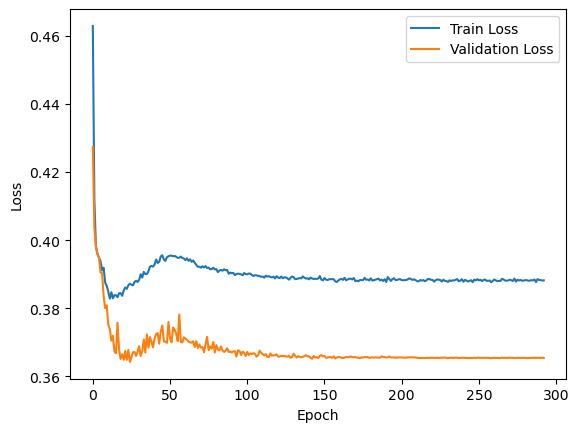

In [105]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [19]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
model = EdgeGNN(node_in_ch=16, sep_emb_dim=8, hidden_ch=128, mlp_hidden_ch=64, GNN_layers=4).to(device)
save_path = "best_model_regressor_sparse_big.pt"
state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
# device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
# model = EdgeGNN(node_in_ch=16, sep_emb_dim=8, hidden_ch=64, mlp_hidden_ch=32, GNN_layers=3).to(device)
# save_path = "best_model_regressor_sparse.pt"
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)

<All keys matched successfully>

In [11]:
def graph_to_matrix(data, values, mask=None):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index

    if mask is not None:
        edge_index = edge_index[:, mask]
        values = values[mask]
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

In [12]:
def loss_per_graph(batch, pred_dist):
    scores = pred_dist.squeeze(-1)
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    loss_tot = []

    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        if g_scores.numel() == 0:
            continue

        loss = torch.mean(torch.abs(g_scores - g_true))  # MAE per graph
        loss_tot.append(loss.item())

    return loss_tot

0.33136193420940313


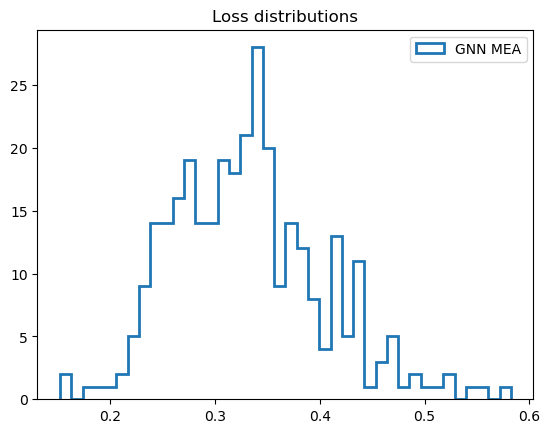

In [20]:
# <<< Ok ma non la chiamerei loss. Non e' la loss con la quale abbiamo fatto il training, ha anche il MSE term mi pare con il lambda
# Se vuoi generalizzare loss_per_graph a usare una qualsiasi loss devi ridefinire la loss corrente come modulo torch.nn

all_losses = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_dist = model(batch)

        loss_tot= loss_per_graph(batch,pred_dist)
        all_losses.extend(loss_tot)

print(np.mean(all_losses))

plt.hist(all_losses, bins=40, histtype='step',linewidth=2, label=f"GNN MEA")


plt.legend()
plt.title("Loss distributions")
plt.show()


In [21]:
sorted_losses = sorted(enumerate(all_losses), key=lambda x: x[1])

# First 3 minimum values and their indices
# First 3 minimum values and their indices
for idx, val in sorted_losses[:3]:
    print(val, idx)

for idx, val in sorted_losses[len(sorted_losses)-3:len(sorted_losses)]:
    print(val, idx)

0.15230099856853485 165
0.16216078400611877 109
0.1743738204240799 124
0.5435065627098083 203
0.5505726933479309 141
0.5823460221290588 189


DataBatch(x=[180, 16], edge_index=[2, 9650], edge_attr=[9650, 2], y=[9650, 1], edge_mask=[9650], pair_mask=[9650], rev_edge_idx=[9650], filename=[1], batch=[180], ptr=[2])


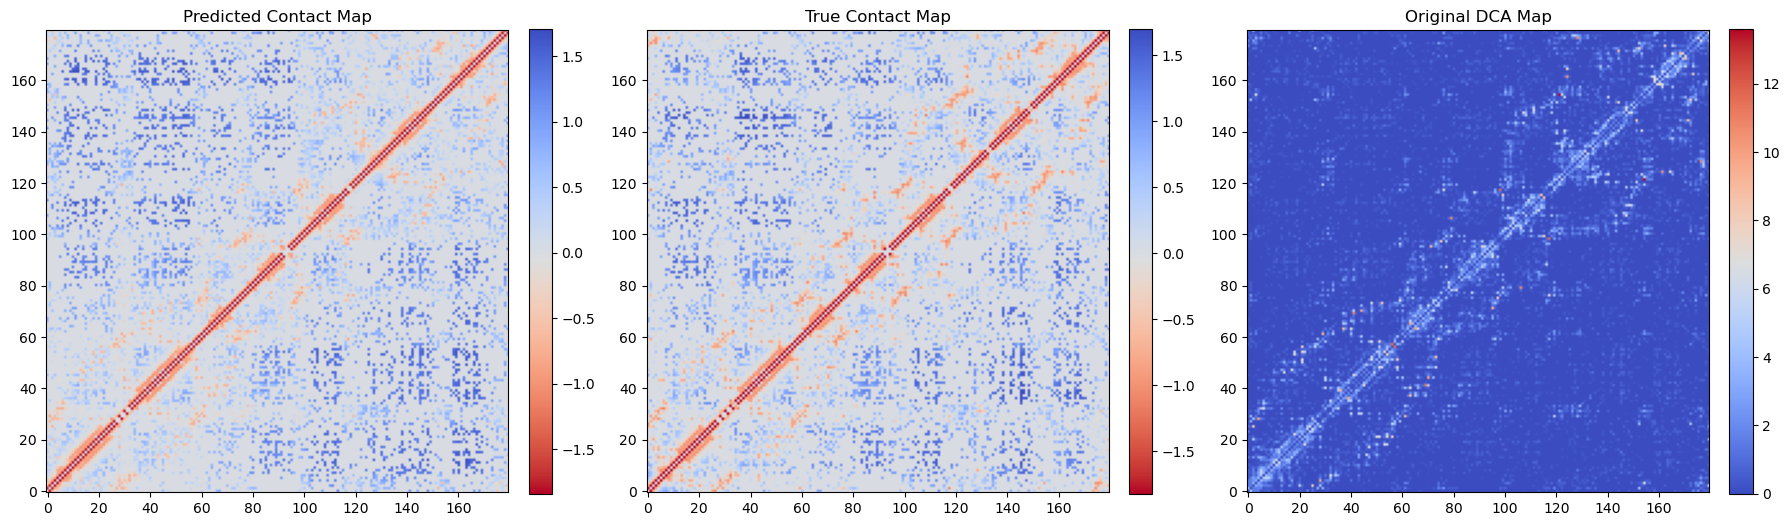

In [22]:
pos=48

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_dist = model(batch)
            break
        i+=1

#batch=train_data[pos]
print(batch)

mask = batch.edge_mask #& batch.pair_mask

pred_dist_map = graph_to_matrix(batch, pred_dist.squeeze(-1).cpu(), mask.cpu())
true_dist_map = graph_to_matrix(batch, batch.y.cpu(),mask.cpu())
original_dca_map = graph_to_matrix(batch, batch.edge_attr[:,0].cpu())


fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_dist_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---


im1 = axes[1].imshow(true_dist_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original DCA Map ---
im2 = axes[2].imshow(original_dca_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Original DCA Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()